# Validation: NumPy vs JAX — Lid-Driven Cavity Flow


1. Load results from both solvers via `run_notebook_cells`
2. Convert JAX arrays → NumPy
3. Save all arrays with `pickle`
4. Compute $\|\mathbf{x}_{\text{JAX}} - \mathbf{x}_{\text{NumPy}}\|_2$
5. Plot spatial distribution of absolute error

## 0 · Notebook Loader

`run_notebook_cells` reads a `.ipynb` file (which is just JSON), iterates over every
**code** cell, and `exec`s it into an isolated namespace dict.  
Pass `stop_on` to halt before any cell whose source contains a given string.

In [1]:
import json

def run_notebook_cells(path: str, stop_on: str = None) -> dict:
    """Execute code cells from *path* into an isolated namespace and return it.

    Parameters
    ----------
    path     : path to the .ipynb file (relative to this notebook's directory)
    stop_on  : if a cell's source contains this string, stop before executing it

    Returns
    -------
    ns : dict — the namespace produced by running the notebook's cells
    """
    with open(path) as f:
        nb = json.load(f)

    ns = {}   # isolated — no cross-contamination between notebooks
    for i, cell in enumerate(nb["cells"]):
        if cell["cell_type"] != "code":
            continue
        src = "".join(cell["source"])
        # Strip Jupyter magics (%matplotlib inline etc.) that exec() can't handle
        src = "\n".join(
            line for line in src.splitlines()
            if not line.strip().startswith("%")
        )
        if stop_on and stop_on in src:
            print(f"  Stopped before cell {i} (trigger: '{stop_on}')")
            break
        try:
            exec(src, ns)
        except Exception as e:
            print(f"  ⚠ Cell {i} skipped — {type(e).__name__}: {e}")
    return ns

## 1 · Load NumPy Solver Results

Runs every cell in `../numpy/07_cavity_flow.out.ipynb` up to (but not including)
the Devito import.  All solver functions and the final arrays live in `np_ns`.

Loading NumPy solver …


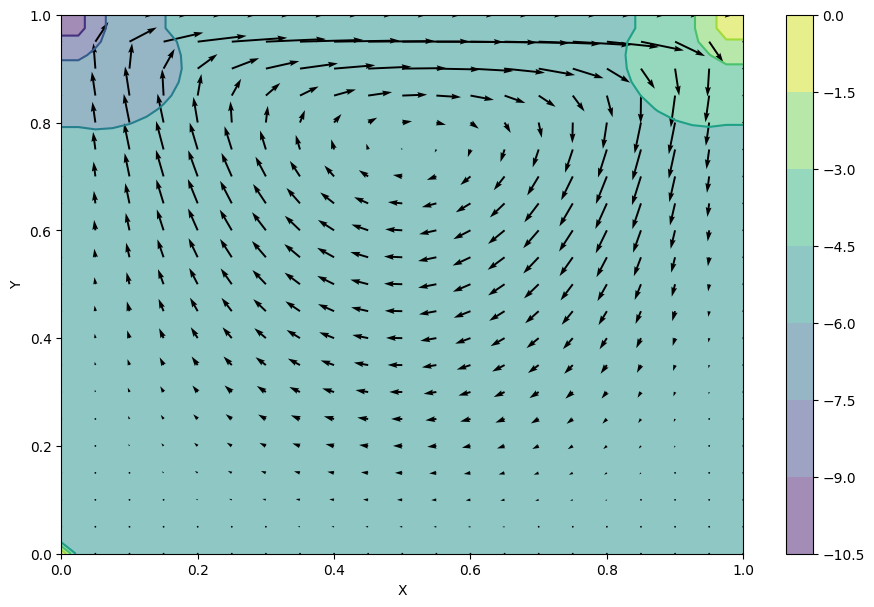

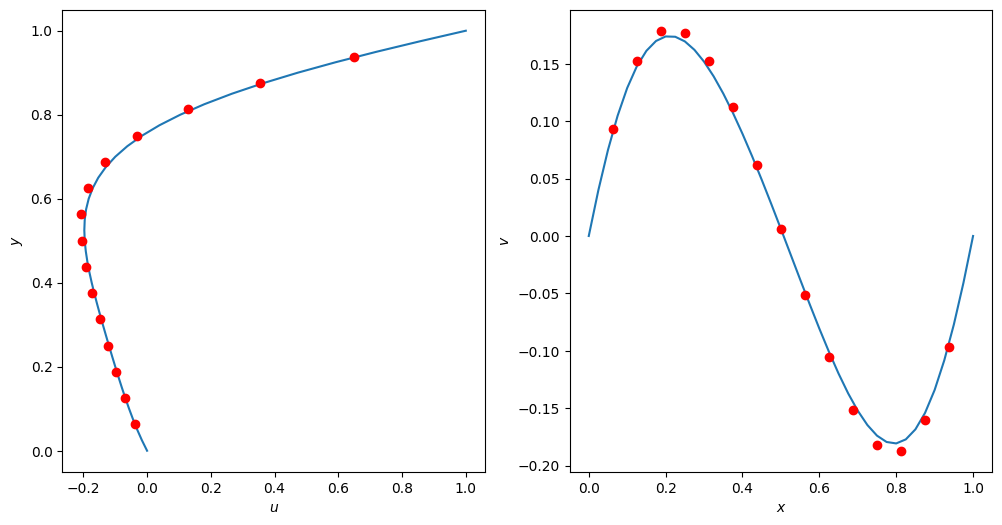

u_np  shape=(41, 41)  dtype=float64


In [2]:
print("Loading NumPy solver …")
np_ns = run_notebook_cells(
    "../numpy/07_cavity_flow.out.ipynb",
    stop_on="from devito",   # don't execute the Devito section
)

# The NumPy notebook stores results as:  a, b, c, d = cavity_flow(...)
u_np = np_ns["a"]   # u-velocity
v_np = np_ns["b"]   # v-velocity
p_np = np_ns["c"]   # pressure

print(f"u_np  shape={u_np.shape}  dtype={u_np.dtype}")

## 2 · Load JAX Solver Results

Runs every code cell in `cavity_flow_jax.ipynb` (same folder).  Results live in `jax_ns`.

Loading JAX solver …
u_sol shape=(41, 41)  dtype=float64


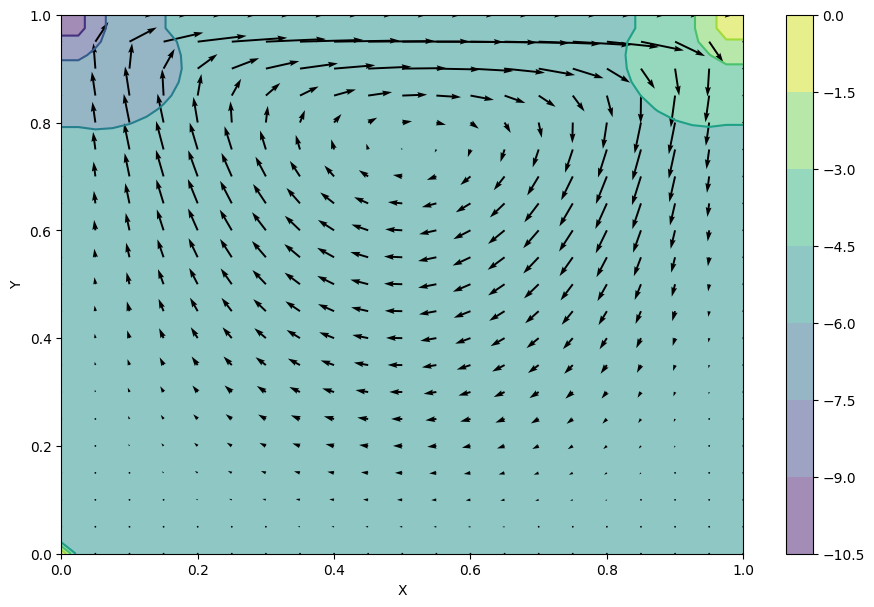

In [ ]:
print("Loading JAX solver …")
jax_ns = run_notebook_cells("cavity_flow_jax.ipynb")

# The JAX notebook stores results as:  u_sol, v_sol, p_sol = cavity_flow(...)
u_sol = jax_ns["u_sol"]   # JAX DeviceArray
v_sol = jax_ns["v_sol"]
p_sol = jax_ns["p_sol"]

print(f"u_sol shape={u_sol.shape}  dtype={u_sol.dtype}")

#plots already look the same

## 3 · Convert JAX Arrays → NumPy

In [4]:
import numpy as np

# np.array() materialises any pending XLA computations and copies to host memory
u_jax_np = np.array(u_sol)
v_jax_np = np.array(v_sol)
p_jax_np = np.array(p_sol)
# horizontal and vertical velocity, pressure
print("Converted — all arrays now in NumPy format.")

Converted — all arrays now in NumPy format.


## 4 · Save Arrays with Pickle

Saved as `cavity_flow_solutions.pkl` next to this notebook (inside `jax/`).

In [5]:
import pickle

# Pull grid metadata from the NumPy namespace (same values in both notebooks)
grid_meta = {k: np_ns[k] for k in ("nx", "ny", "dx", "dy", "nt", "dt", "rho", "nu")}

arrays = {
    "u_np":  u_np,
    "v_np":  v_np,
    "p_np":  p_np,
    "u_jax": u_jax_np,
    "v_jax": v_jax_np,
    "p_jax": p_jax_np,
    "grid":  grid_meta,
}

with open("cavity_flow_solutions.pkl", "wb") as f:
    pickle.dump(arrays, f)

# Reload sanity check
with open("cavity_flow_solutions.pkl", "rb") as f:
    chk = pickle.load(f)
assert np.allclose(chk["u_np"], u_np)
print("Saved cavity_flow_solutions.pkl  ✓")

Saved cavity_flow_solutions.pkl  ✓


## 5 · Error Analysis — L2 Norms

$$\|\mathbf{e}\|_2 = \sqrt{\sum_{i,j} \left(x^{\text{JAX}}_{i,j} - x^{\text{NumPy}}_{i,j}\right)^2}$$

In [ ]:
from jax._src.core import Value


err_u = u_jax_np - u_np
err_v = v_jax_np - v_np
err_p = p_jax_np - p_np

print("┌─────────────┬─────────────────┬─────────────────┬─────────────────┐")
print("│  Field      │  L2 norm error  │  Relative error │  Max abs error  │")
print("├─────────────┼─────────────────┼─────────────────┼─────────────────┤")



for label, err, ref in [("u", err_u, u_np), ("v", err_v, v_np), ("p", err_p, p_np)]:
    l2  = np.linalg.norm(err)
    rel = l2 / (np.linalg.norm(ref) + 1e-16)
    mx  = np.max(np.abs(err))
    print(f"│  {label:<11}│  {l2:<15.4e}│  {rel:<15.4e}│  {mx:<15.4e}│")

    
print("└─────────────┴─────────────────┴─────────────────┴─────────────────┘")
#l2 norm is overall error magniuted across all entries = sqrt(sum((y^i-yi)^2))
#realative error- scales error compared to size of true Value = ||y^-y||/ ||y||
#max abs error - worst case error = max[y^i - yi]

┌─────────────┬─────────────────┬─────────────────┬─────────────────┐
│  Field      │  L2 norm error  │  Relative error │  Max abs error  │
├─────────────┼─────────────────┼─────────────────┼─────────────────┤
│  u          │  0.0000e+00     │  0.0000e+00     │  0.0000e+00     │
│  v          │  0.0000e+00     │  0.0000e+00     │  0.0000e+00     │
│  p          │  0.0000e+00     │  0.0000e+00     │  0.0000e+00     │
└─────────────┴─────────────────┴─────────────────┴─────────────────┘


## 7 · Velocity Profiles — NumPy vs JAX

Both curves should be visually indistinguishable if the implementations agree.

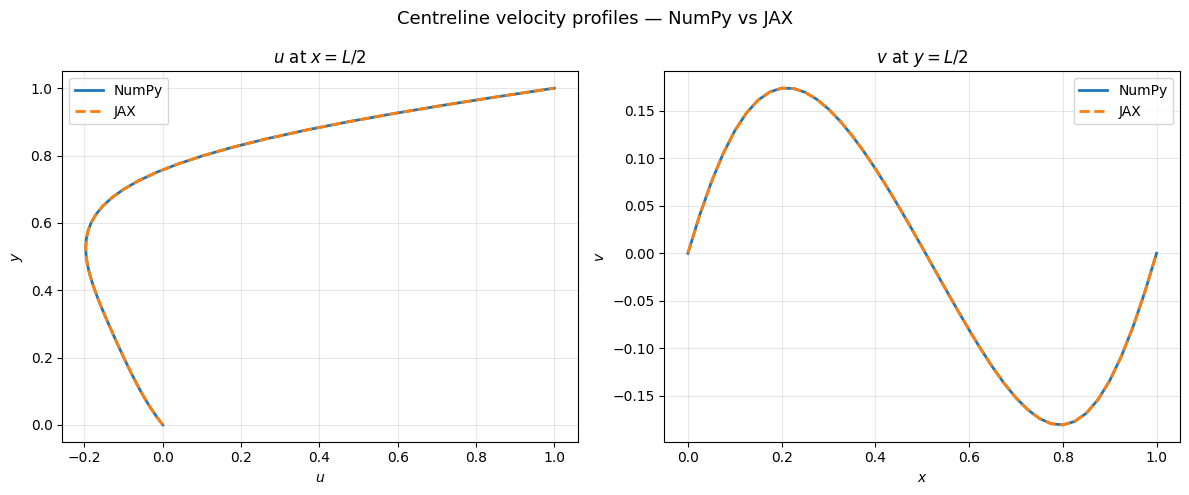

In [8]:
mid = nx // 2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Centreline velocity profiles — NumPy vs JAX", fontsize=13)

ax1.plot(u_np[mid, :],     y_coord, label="NumPy", lw=2)
ax1.plot(u_jax_np[mid, :], y_coord, "--", label="JAX", lw=2)
ax1.set_xlabel(r"$u$"); ax1.set_ylabel(r"$y$")
ax1.set_title(r"$u$ at $x = L/2$"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(x_coord, v_np[:, mid],     label="NumPy", lw=2)
ax2.plot(x_coord, v_jax_np[:, mid], "--", label="JAX", lw=2)
ax2.set_xlabel(r"$x$"); ax2.set_ylabel(r"$v$")
ax2.set_title(r"$v$ at $y = L/2$"); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()